## runMSLM_ice
Prediction of pan-Arctic sea ice extent using DAHD + MSLM forecasting.

**Pipeline:**
1. Read and preprocess Arctic sea ice extent data from Excel.
2. Build 7 regional composites and trim to analysis period.
3. Plot raw sea ice extent (Fig 1).
4. Center data, remove seasonal cycle, compute anomalies.
5. Run DAHD spectral analysis — spectrum (Fig 2) and space-time modes (Figs 3-4).
6. Run MSLM stochastic forecast over 20 frequency bins with 600 ensemble members.
7. Post-process: add back seasonal cycle, zero negative SIE, compute anomalies.
8. Plot forecast vs observations (Fig 5), September prediction summary, histogram.

**Dependencies:** `DAHD4freq_part_weight`, `DAHM4_ex`, `MSLM_FCST`, `dahc`, `hrc`

**Data files required:** `N_Sea_Ice_Index_Regional_Daily_Data_G02135-2024June17.xlsx`, `ROBSF.mat`

**References:**
- Kondrashov D. et al. 2026: *Accurate and robust real-time prediction of September Arctic sea ice.* Chaos, 36. doi:10.1063/5.0295634

In [135]:
import importlib, MSLM_FCST
importlib.reload(MSLM_FCST)
from MSLM_FCST import MSLM_FCST
print("reloaded!")

reloaded!


In [136]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import interp1d
import openpyxl

from DAHD4freq_part_weight import DAHD4freq_part_weight
from DAHM4_ex import DAHM4_ex
from MSLM_FCST import MSLM_FCST
from dahc import dahc
from hrc import hrc

### 1. Read Arctic Sea Ice Data
Read 14 Extent sheets from Excel. For each year column, compute 52 weekly means from 364 daily values, then stack all years sequentially.

In [137]:
EXCEL_FILE = 'N_Sea_Ice_Index_Regional_Daily_Data_G02135-2024June17.xlsx'
wb         = openpyxl.load_workbook(EXCEL_FILE, data_only=True)
sheet_idx  = list(range(1, 28, 2))   # 14 Extent sheets (0-indexed: 1,3,5,...,27)

all_weekly = []
for si in sheet_idx:
    ws     = wb.worksheets[si]
    rows   = list(ws.iter_rows(values_only=True))
    header = rows[0]
    n_yr   = len([c for c in header[2:] if isinstance(c, (int, float))])
    num0   = []
    for row in rows[1:365]:
        num0.append([
            float(v) if isinstance(v, (int, float)) and v is not None else np.nan
            for v in row[2:2 + n_yr]
        ])
    num0   = np.array(num0, dtype=float)
    weekly = np.zeros((52, n_yr))
    for yr in range(n_yr):
        weekly[:, yr] = num0[:, yr].reshape(52, 7).mean(axis=1)
    all_weekly.append(weekly.T.reshape(-1))

max_len = max(len(a) for a in all_weekly)
extent  = np.full((max_len, 14), np.nan)
for k, a in enumerate(all_weekly):
    extent[:len(a), k] = a

print(f"extent shape: {extent.shape}")

extent shape: (2444, 14)


### 2. Interpolate Missing Values and Build Regional Composites

In [138]:
data = np.copy(extent)
for kk in range(14):
    tmp  = extent[:, kk]
    indm = np.where(np.isnan(tmp))[0]
    indf = np.where(~np.isnan(tmp))[0]
    if len(indm) > 0 and len(indf) > 1:
        f = interp1d(indf, tmp[indf], bounds_error=False, fill_value='extrapolate')
        data[indm, kk] = f(indm)

nan_ind      = np.where(np.isnan(data[:, 0]))[0]
NN           = nan_ind[0] if len(nan_ind) > 0 else data.shape[0]
data         = data[:NN - 1, :]
data[-1, 13] = data[-2, 13]

iceCEN = data[:, 5]
iceA   = data[:, 2]  + data[:, 6]
iceB   = data[:, 4]
iceC   = data[:, 1]  + data[:, 10]
iceD   = data[:, 11] + data[:, 7]
iceE   = data[:, 0]
iceF   = data[:, 8]
iceG   = data[:, 3]  + data[:, 9] + data[:, 12] + data[:, 13]

ICET      = np.column_stack([iceA, iceB, iceC, iceD, iceE + iceF, iceG])
iceextobs = np.column_stack([iceCEN, ICET])
DD        = iceextobs.shape[1]

iceextobs = iceextobs[1404:, :]
iceext    = iceextobs.copy()
weeks     = np.arange(1, iceext.shape[0] + 1)
yearst    = 2006 + weeks / 52
print(f"iceextobs shape: {iceextobs.shape}, DD={DD}")

iceextobs shape: (1039, 7), DD=7


### Fig 1 — Raw Sea Ice Extent
Melt curves weeks 20-40 for 7 regions + pan-Arctic. Red = historical, blue = last year, green = 2012 minimum, black = current year.

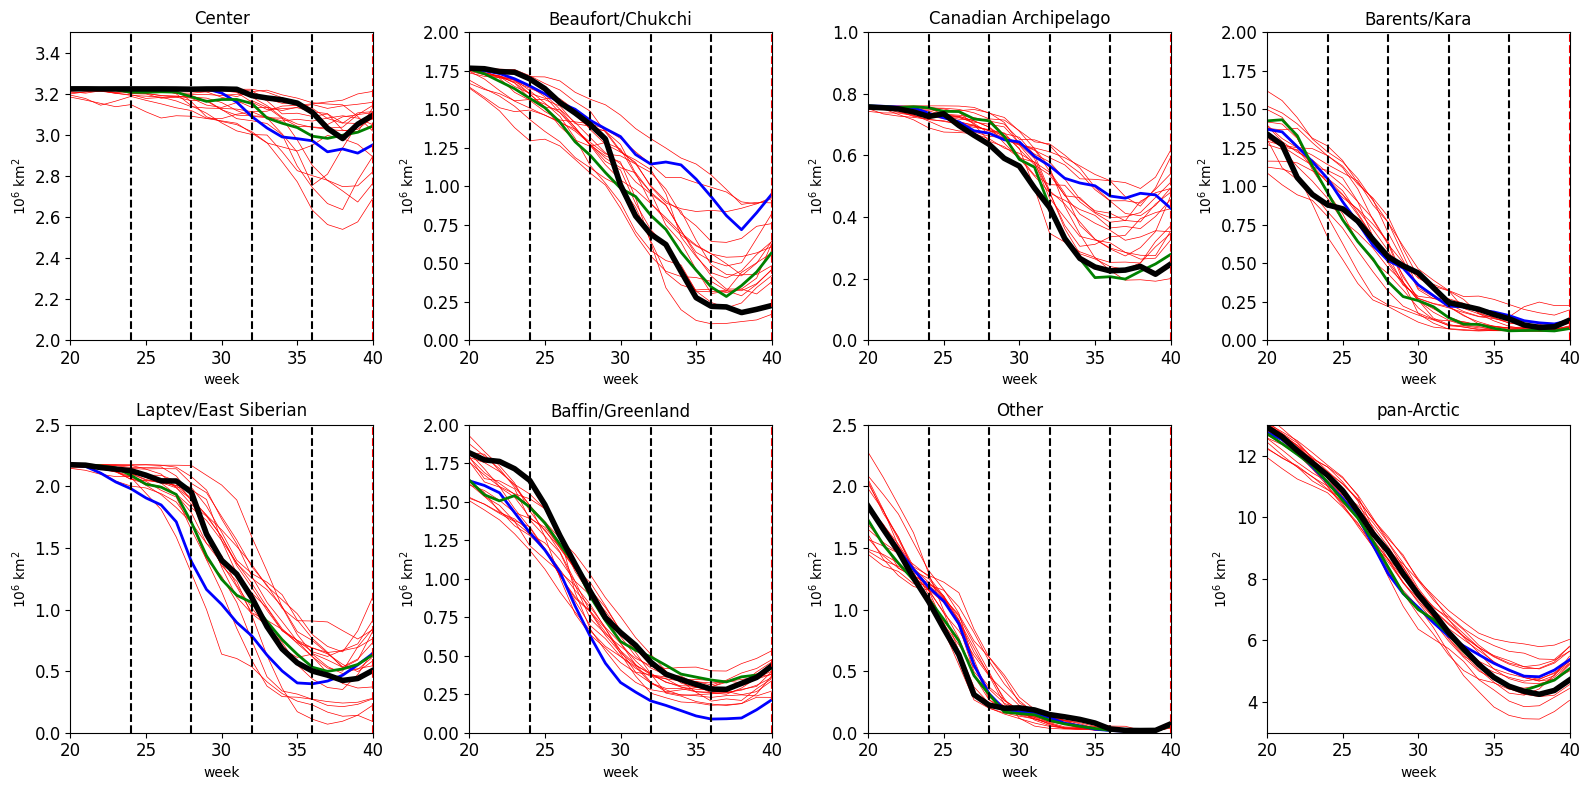

In [139]:
n_hist  = 728 + 52 * 4
n_years = n_hist // 52
iceyear = iceextobs[:n_hist, :].reshape(n_years, 52, DD).transpose(1, 0, 2)
ice2021 = iceextobs[n_hist:, :]
tweek   = ice2021.shape[0]

titles = ['Center', 'Beaufort/Chukchi', 'Canadian Archipelago',
          'Barents/Kara', 'Laptev/East Siberian', 'Baffin/Greenland', 'Other']
ylims  = [(2, 3.5), (0, 2), (0, 1), (0, 2), (0, 2.5), (0, 2), (0, 2.5)]
wk_slice = slice(19, 40)
x_weeks  = np.arange(20, 41)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for k in range(DD):
    ax = axes.flat[k]
    ax.plot(x_weeks, iceyear[wk_slice, :, k] / 1e6, 'r', linewidth=0.5)
    ax.plot(x_weeks, iceyear[wk_slice, -2, k] / 1e6, 'b', linewidth=2)
    ax.plot(x_weeks, iceyear[wk_slice,  6, k] / 1e6, 'g', linewidth=2)
    n_cur = min(tweek - 19, len(x_weeks))
    if n_cur > 0:
        ax.plot(x_weeks[:n_cur], ice2021[19:19 + n_cur, k] / 1e6, 'k', linewidth=4)
    ax.axvline(min(tweek, 40), color='r', linestyle='--')
    for wk in [24, 28, 32, 36]:
        if tweek > wk: ax.axvline(wk, color='k', linestyle='--')
    ax.set_title(titles[k] if k < len(titles) else f'Region {k+1}')
    ax.set_xlim([20, 40]); ax.set_xlabel('week'); ax.set_ylabel('10$^6$ km$^2$')
    if k < len(ylims): ax.set_ylim(ylims[k])
    ax.tick_params(labelsize=12)

ax = axes.flat[7]
ax.plot(x_weeks, np.sum(iceyear[wk_slice, :, :], axis=2)           / 1e6, 'r', linewidth=0.5)
ax.plot(x_weeks, np.sum(iceyear[wk_slice, -2, :], axis=1)          / 1e6, 'b', linewidth=2)
ax.plot(x_weeks, np.sum(iceyear[wk_slice,  6, :], axis=1)          / 1e6, 'g', linewidth=2)
n_cur = min(tweek - 19, len(x_weeks))
if n_cur > 0:
    ax.plot(x_weeks[:n_cur], np.sum(ice2021[19:19+n_cur, :], axis=1) / 1e6, 'k', linewidth=4)
ax.set_title('pan-Arctic'); ax.set_xlim([20, 40]); ax.set_ylim([3, 13])
ax.set_xlabel('week'); ax.set_ylabel('10$^6$ km$^2$'); ax.tick_params(labelsize=12)
plt.tight_layout(); plt.show()

### 3. Forecast Setup and Seasonal Cycle Removal

In [140]:
# TARG = 767 + 4 * 52
# KT   = iceext.shape[0]
# LEAD = TARG - KT

LEAD = 20
KT   = iceext.shape[0]
TARG = KT + LEAD

KF   = KT

yearst_full = np.append(yearst, np.arange(1, LEAD + 1) / 52 + yearst[KF - 1])
iceext  = iceextobs[:KF, :]
icemean = np.mean(iceext, axis=0)

iceext_c = iceext - icemean
anom     = np.zeros_like(iceext_c)
scycle   = np.zeros((52, DD))
icycle   = 1

for j in range(DD):
    for i in range(52):
        idx           = np.arange(i, iceext_c.shape[0], 52)
        scycle[i, j]  = np.mean(iceext_c[idx, j])
        anom[idx, j]  = iceext_c[idx, j] - scycle[i, j]

X = anom
print(f"X shape: {X.shape}, LEAD={LEAD}")

X shape: (1039, 7), LEAD=20


### Fig 2 — DAHD Spectrum
Eigenvalue spectrum vs frequency. High values at low frequencies show dominant seasonal cycles in Arctic sea ice data.

Running DAHD spectral analysis...
0 >0:7 <0:0
1 >0:7 <0:0
2 >0:7 <0:0
3 >0:7 <0:0
4 >0:7 <0:0
5 >0:7 <0:0
6 >0:7 <0:0
7 >0:7 <0:0
8 >0:7 <0:0
9 >0:7 <0:0
10 >0:7 <0:0
11 >0:7 <0:0
12 >0:7 <0:0
13 >0:7 <0:0
14 >0:7 <0:0
15 >0:7 <0:0
16 >0:7 <0:0
17 >0:7 <0:0
18 >0:7 <0:0
19 >0:7 <0:0
20 >0:7 <0:0
21 >0:7 <0:0
22 >0:7 <0:0
23 >0:7 <0:0
24 >0:7 <0:0
25 >0:7 <0:0
26 >0:7 <0:0
27 >0:7 <0:0
28 >0:7 <0:0
29 >0:7 <0:0
30 >0:7 <0:0
31 >0:7 <0:0
32 >0:7 <0:0
33 >0:7 <0:0
34 >0:7 <0:0
35 >0:7 <0:0
36 >0:7 <0:0
37 >0:7 <0:0
38 >0:7 <0:0


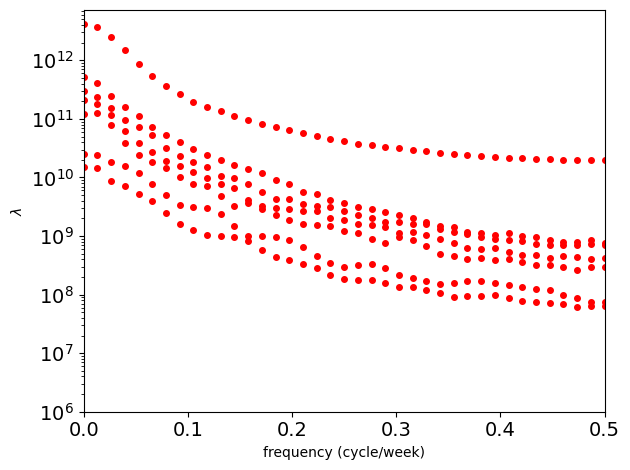

In [141]:
W   = 39
WW  = 2 * W - 1
D   = X.shape[1]
NP  = D
NFE = W
wt  = 'bartlett'

print("Running DAHD spectral analysis...")
fE2, VP, FEP = DAHD4freq_part_weight(X, W, NFE, NP, wt)

plt.figure()
plt.semilogy(fE2, np.abs(VP).T, 'ro', markersize=4, markerfacecolor='r')
plt.ylabel(r'$\lambda$'); plt.xlim([0, 0.5]); plt.ylim(bottom=1e6)
plt.xlabel('frequency (cycle/week)'); plt.tick_params(labelsize=14)
plt.tight_layout(); plt.show()

### Compute Space-Time DAHMs

In [142]:
NP = D
EP = np.zeros(((2 * W - 1) * D, 2 * NP, NFE))
print("Computing DAHMs...")
for iff in range(NFE):
    ER  = DAHM4_ex(FEP[:, :, iff], W, iff, 2 * NP)
    EP[:, :, iff] = np.reshape(ER, ((2 * W - 1) * D, 2 * NP))
print(f"EP shape: {EP.shape}")

Computing DAHMs...
EP shape: (539, 14, 39)


### Fig 3 — DAHM Eigenvectors (f=0.11-0.20)
Space-time structure of 8 leading DAHM pairs at mid-range frequencies.

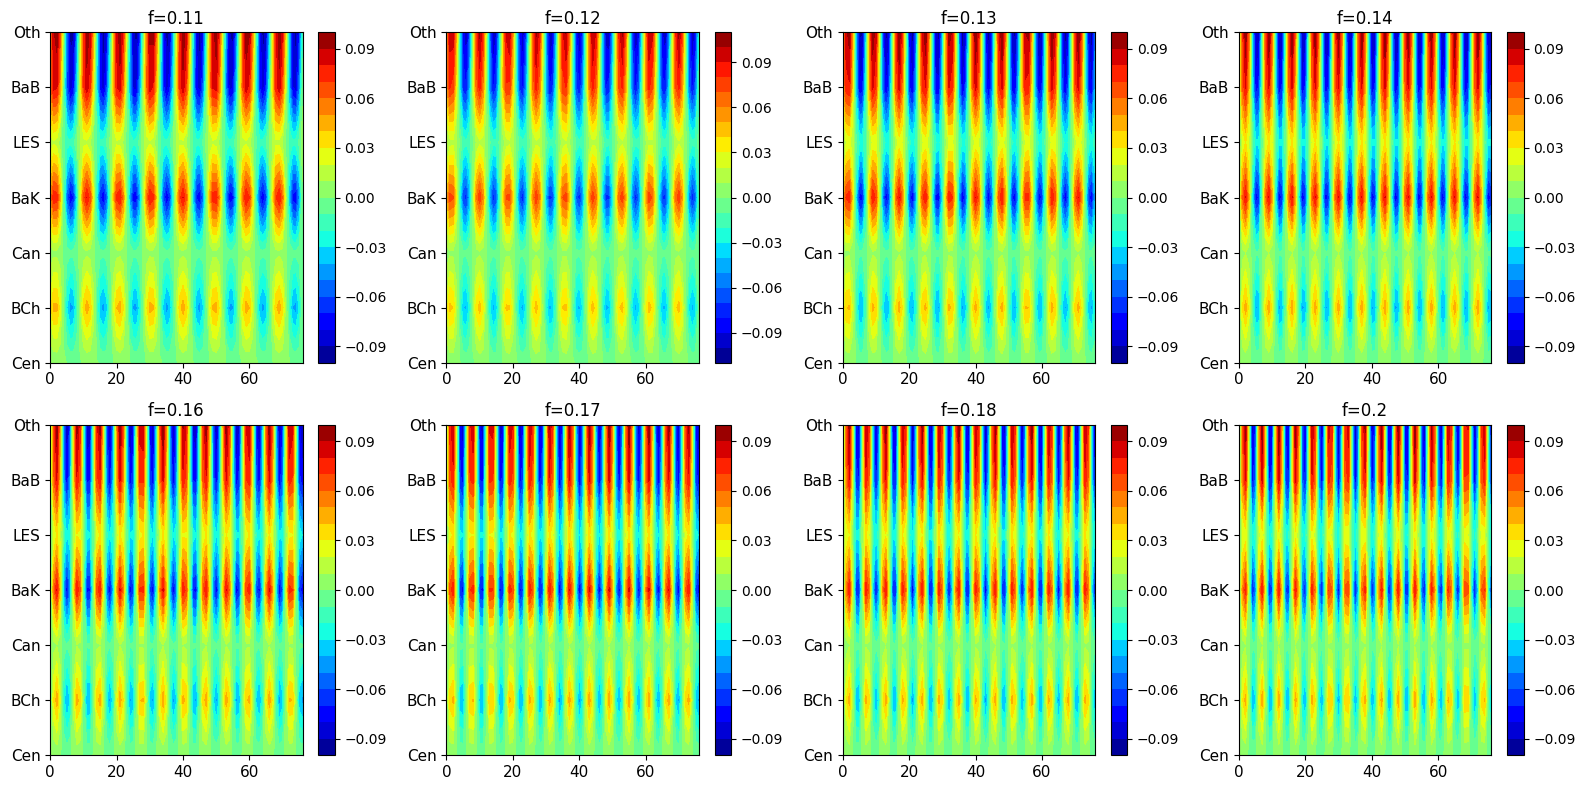

In [143]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for NFFF, NF in enumerate(range(8, 16)):
    ax = axes.flat[NFFF]
    cf = ax.contourf(np.reshape(EP[:, 1, NF], (WW, D)).T, 20, cmap='jet')
    plt.colorbar(cf, ax=ax)
    ax.set_title(f'f={round(fE2[NF], 2)}')
    ax.set_yticks(range(D))
    ax.set_yticklabels(['Cen', 'BCh', 'Can', 'BaK', 'LES', 'BaB', 'Oth'][:D])
    ax.tick_params(labelsize=11)
plt.tight_layout(); plt.show()

### Fig 4 — DAHM Eigenvector Pairs (4x4 grid)
Rows 1-2: first eigenvector at odd frequencies; rows 3-4: quadrature pair. Each pair is in exact phase quadrature.

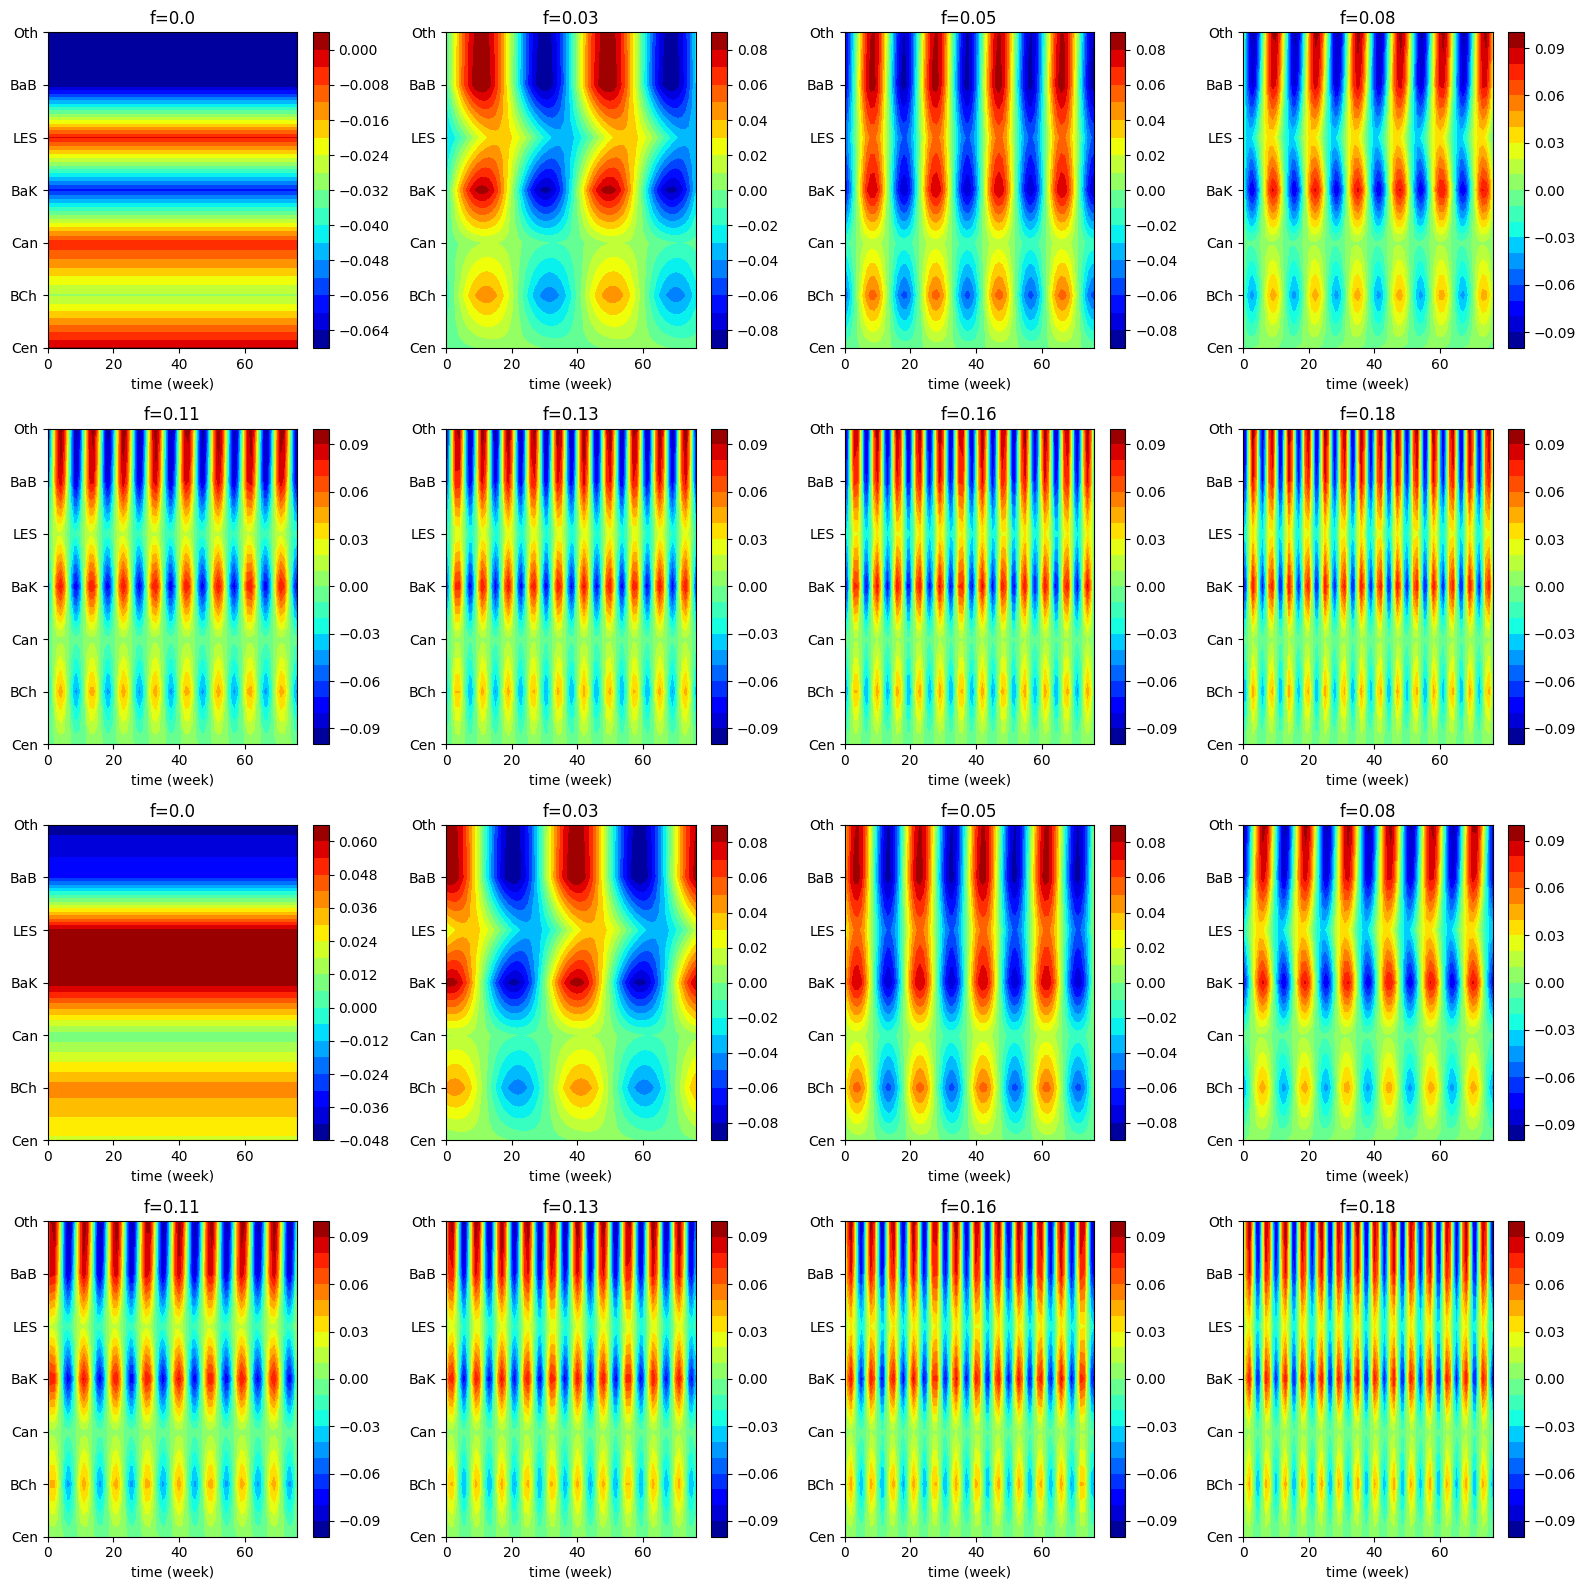

In [144]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
NFFF = 0
for NF in range(0, 15, 2):
    ax = axes[0, NFFF] if NF <= 6 else axes[1, NFFF - 4]
    cf = ax.contourf(np.reshape(EP[:, 0, NF], (WW, D)).T, 20, cmap='jet')
    plt.colorbar(cf, ax=ax); ax.set_title(f'f={round(fE2[NF], 2)}')
    ax.set_xlabel('time (week)'); ax.set_yticks(range(D))
    ax.set_yticklabels(['Cen', 'BCh', 'Can', 'BaK', 'LES', 'BaB', 'Oth'][:D])
    ax.tick_params(labelsize=10); NFFF += 1

NFFF = 0
for NF in range(0, 15, 2):
    ax = axes[2, NFFF] if NF <= 6 else axes[3, NFFF - 4]
    cf = ax.contourf(np.reshape(EP[:, 1, NF], (WW, D)).T, 20, cmap='jet')
    plt.colorbar(cf, ax=ax); ax.set_title(f'f={round(fE2[NF], 2)}')
    ax.set_xlabel('time (week)'); ax.set_yticks(range(D))
    ax.set_yticklabels(['Cen', 'BCh', 'Can', 'BaK', 'LES', 'BaB', 'Oth'][:D])
    ax.tick_params(labelsize=10); NFFF += 1
plt.tight_layout(); plt.show()

### MSLM Forecast
Run Multi-Level Stochastic Stuart-Landau Model over 20 frequency bins with 600 ensemble members. NF=0 uses linear model; NF>0 uses Stuart-Landau with symmetry and nonlinear constraints.

In [145]:
NFS_fcst = 0
NFE_fcst = 20
NT0      = 600
inorm    = 1; ires = 0; iSYM = 1; iNL = 1; inEQ = 1; L_lvl = 2

# FIX: set LEAD to 20 weeks ahead — original TARG was hardcoded for 2024
# but data now extends past it, giving LEAD=-64
LEAD = 20
KT   = iceext.shape[0]
TARG = KT + LEAD

NA  = X.shape[0] - EP.shape[0] // D + 1
NE  = NA + LEAD
NXT = NE + EP.shape[0] // D - 1
print(f"NA={NA}, NE={NE}, NXT={NXT}, LEAD={LEAD}")

RXT = np.zeros((NXT, DD, NFE_fcst - NFS_fcst, NT0))
RRT = np.zeros((X.shape[0], DD, NFE_fcst - NFS_fcst))
AXT = np.zeros((NE, 2, NT0, NFE_fcst - NFS_fcst))
np.random.seed(0)

print("Running MSLM forecast...")
for NF in range(NFS_fcst, NFE_fcst):
    print(f"  NF={NF+1}/{NFE_fcst}")
    NM = D if NF == 0 else 2 * D
    ncmp = NM; ER = EP[:, :NM, NF]; A = dahc(X, ER)
    indm = np.arange(ncmp)
    RR_f = hrc(A, ER, DD, indm); n = min(RR_f.shape[0], X.shape[0])
    RRT[:n, :, NF - NFS_fcst] = RR_f[:n, :]
    DMD = A[:, indm]
    np.random.seed(0)
    if ires == 0:
        indrandperm = np.random.randn(ncmp, NE, NT0)
    else:
        indrandperm = np.zeros((NA - 1, NT0), dtype=int)
        for nt in range(NT0):
            indrandperm[:, nt] = np.random.permutation(NA - 1)
    if NF == 0:
        xx, xt_res, LL, _ = MSLM_FCST(LEAD, DMD, 0, L_lvl, NT0, ires, inorm, 0, 0, 0, indrandperm)
    else:
        xx, xt_res, LL, ENL = MSLM_FCST(LEAD, DMD, 1, L_lvl, NT0, ires, inorm, iSYM, iNL, inEQ, indrandperm)
    AXT[:, :2, :, NF - NFS_fcst] = xx[:NE, :2, :]
    RXZ = np.zeros((NXT, DD, NT0))
    for KK in range(NT0):
        RXZ[:min(xx.shape[0], NXT), :, KK] = hrc(
            xx[:, indm, KK], ER[:, indm], DD, np.arange(A[:, indm].shape[1])
        )[:min(xx.shape[0], NXT), :]
    RXT[:, :, NF - NFS_fcst, :] = RXZ
print("Forecast complete!")

NA=963, NE=983, NXT=1059, LEAD=20
Running MSLM forecast...
  NF=1/20
  NF=2/20


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  NF=3/20
  NF=4/20
  NF=5/20
  NF=6/20
  NF=7/20
  NF=8/20
  NF=9/20
  NF=10/20
  NF=11/20
  NF=12/20
  NF=13/20
  NF=14/20
  NF=15/20
  NF=16/20
  NF=17/20
  NF=18/20
  NF=19/20
  NF=20/20
Forecast complete!


### Post-Processing
Sum across frequencies, add back seasonal cycle and mean, zero negative SIE.

In [146]:
NET  = X.shape[0]
indf = np.arange(NFE_fcst - NFS_fcst)
RR   = np.sum(RRT[:, :, indf], axis=2)
RX   = np.sum(RXT[:, :, indf, :], axis=2)

if icycle == 1:
    for j in range(DD):
        for i in range(52):
            idx = np.arange(i, RR.shape[0], 52); idx = idx[idx < RR.shape[0]]
            RR[idx, j] += scycle[i, j]
            for k in range(NT0):
                idx2 = np.arange(i, RX.shape[0], 52); idx2 = idx2[idx2 < RX.shape[0]]
                RX[idx2, j, k] += scycle[i, j]

RX0 = RX.copy()
tmp = icemean
for k in range(NT0): RX0[:, :, k] += tmp
RX0[RX0 < 0] = 0
RX00 = RX0.copy()
for k in range(NT0): RX00[:, :, k] -= tmp

RXRC  = np.sum(RXT[:, :, indf, :], axis=2)
RXC   = np.squeeze(np.sum(RXRC, axis=1))
RXRMC = np.squeeze(np.sum(np.mean(RXT[:, :, indf, :], axis=3), axis=2))
RXMC  = np.sum(RXRMC, axis=1)
RXX   = np.squeeze(np.sum(RX, axis=1))
print(f"Post-processing complete. RXRC shape: {RXRC.shape}")

Post-processing complete. RXRC shape: (1059, 7, 600)


### Fig 5 — Forecast vs Observations
Cyan = ensemble members, red = ensemble mean, black = observed anomalies (ROBSRF).

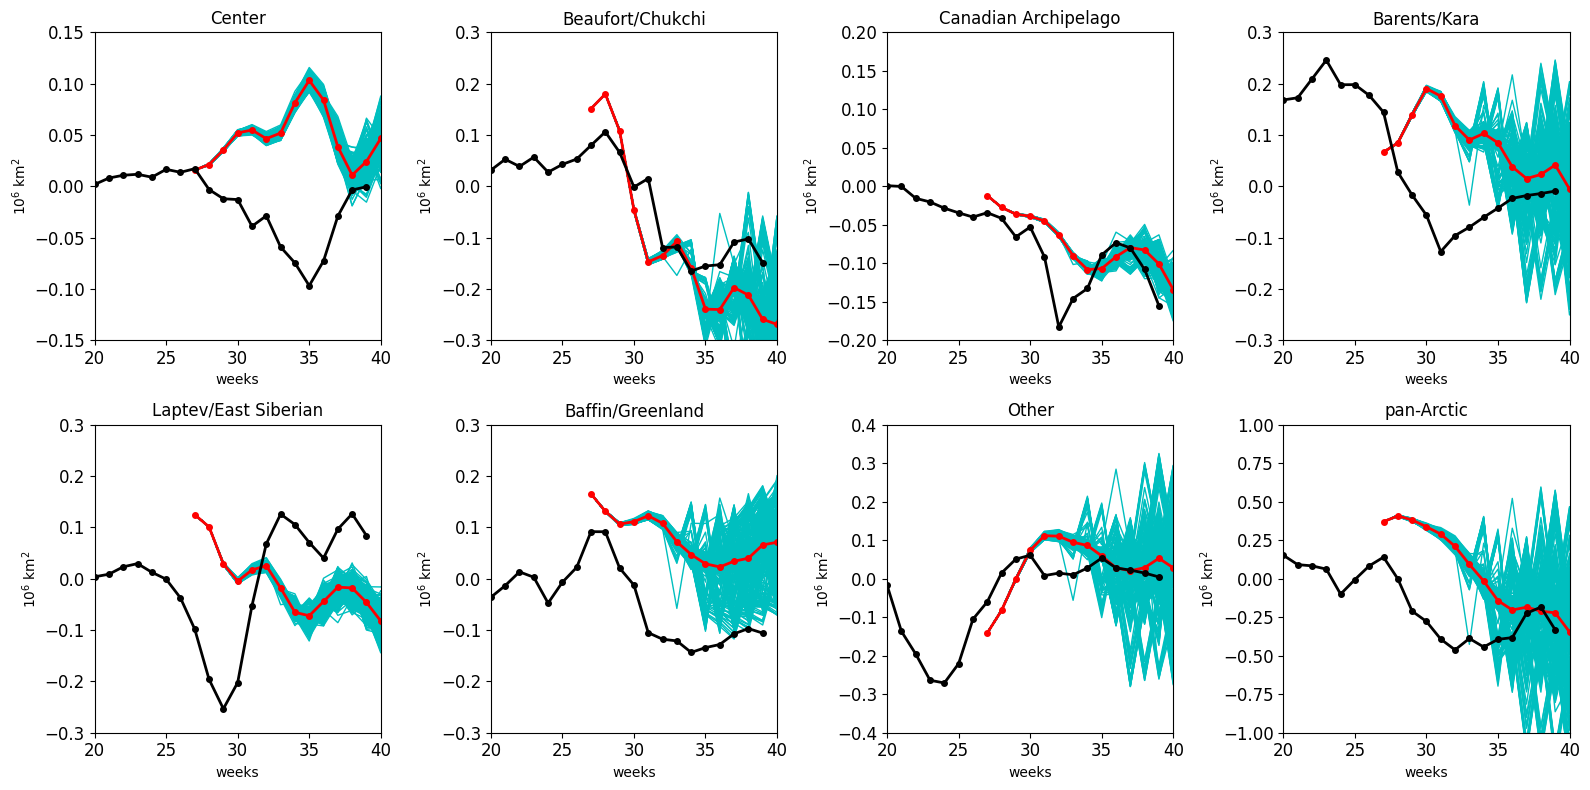

Forecast weeks: 27 to 47


In [181]:
# ── Fig 5 — Forecast vs Observations ─────────────────────────────────────────
mat    = scipy.io.loadmat('ROBSF.mat')
ROBSF  = mat['ROBSF'].ravel()
ROBSRF = mat['ROBSRF']

lmax     = RXRC.shape[0]
t_full   = yearst_full[:lmax]
NET_plot = NA - 1

# Convert forecast rows to week numbers (20-40)
forecast_rows  = np.arange(NET_plot, NET_plot + LEAD + 1)
forecast_weeks = np.round((t_full[forecast_rows] % 1) * 52).astype(int)

# Include a few obs rows before forecast for context
obs_rows  = np.arange(NET_plot - 10, NET_plot + LEAD + 1)
obs_rows  = obs_rows[(obs_rows >= 0) & (obs_rows < min(len(ROBSRF), lmax))]
obs_weeks = np.round((t_full[obs_rows] % 1) * 52).astype(int)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
ylims2 = [(-0.15, 0.15), (-0.3, 0.3), (-0.2, 0.2),
          (-0.3, 0.3),   (-0.3, 0.3), (-0.3, 0.3), (-0.4, 0.4)]

for kk in range(DD):
    ax = axes.flat[kk]
    ax.plot(forecast_weeks,
            np.squeeze(RXRC[forecast_rows, kk, :]) / 1e6,
            'c-', linewidth=1)
    ax.plot(forecast_weeks,
            RXRMC[forecast_rows, kk] / 1e6,
            'r.-', markersize=8, linewidth=2)
    ax.plot(obs_weeks, ROBSRF[obs_rows, kk] / 1e6,
            'k.-', markersize=8, linewidth=2)
    ax.set_title(titles[kk] if kk < len(titles) else f'Region {kk+1}')
    if kk < len(ylims2): ax.set_ylim(ylims2[kk])
    ax.set_xlim([20, 40])
    ax.set_xticks([20, 25, 30, 35, 40])
    ax.set_xlabel('weeks'); ax.set_ylabel('10$^6$ km$^2$')
    ax.tick_params(labelsize=12)

ax = axes.flat[7]
ax.plot(forecast_weeks, RXC[forecast_rows, :] / 1e6, 'c-', linewidth=1)
ax.plot(forecast_weeks, RXMC[forecast_rows]   / 1e6, 'r.-', markersize=8, linewidth=2)
ax.plot(obs_weeks, ROBSF[obs_rows] / 1e6, 'k.-', markersize=8, linewidth=2)
ax.set_title('pan-Arctic'); ax.set_ylim([-1, 1])
ax.set_xlim([20, 40]); ax.set_xticks([20, 25, 30, 35, 40])
ax.set_xlabel('weeks'); ax.set_ylabel('10$^6$ km$^2$')
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

print(f"Forecast weeks: {forecast_weeks[0]} to {forecast_weeks[-1]}")

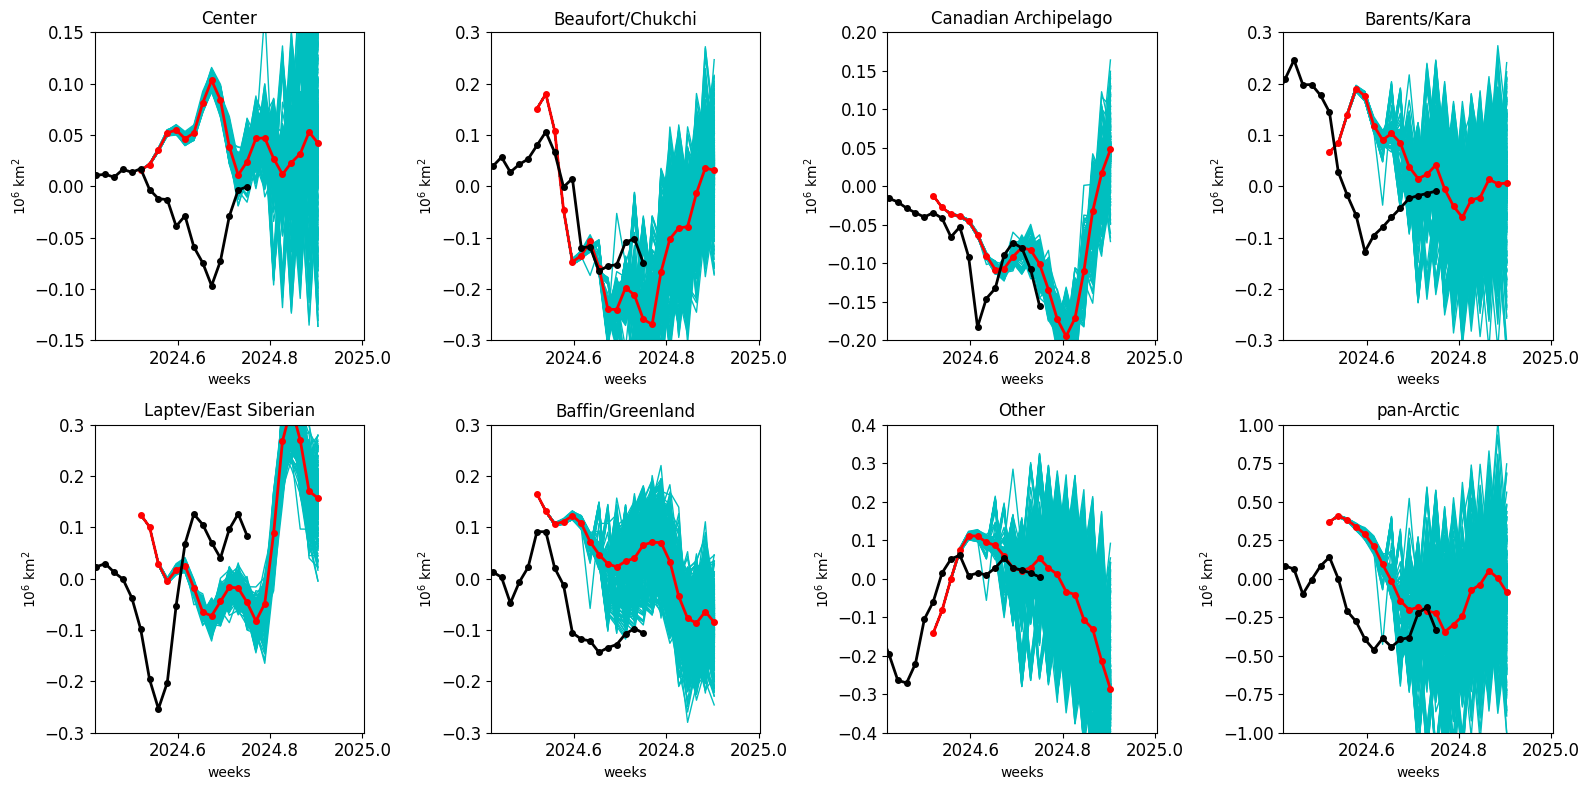

NET_plot=962, LEAD=20
Forecast window: 2024.52 to 2024.90


In [148]:
# ── Fig 5 — Forecast vs Observations ─────────────────────────────────────────
mat    = scipy.io.loadmat('ROBSF.mat')
ROBSF  = mat['ROBSF'].ravel()
ROBSRF = mat['ROBSRF']

lmax     = RXRC.shape[0]
t_full   = yearst_full[:lmax]
NET_plot = NA - 1

# x-axis limits: show only the forecast window + small buffer
x_start = t_full[NET_plot] - 0.1
x_end   = t_full[min(NET_plot + LEAD, lmax - 1)] + 0.1

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
ylims2 = [(-0.15, 0.15), (-0.3, 0.3), (-0.2, 0.2),
          (-0.3, 0.3),   (-0.3, 0.3), (-0.3, 0.3), (-0.4, 0.4)]

for kk in range(DD):
    ax = axes.flat[kk]
    # Ensemble members (cyan)
    ax.plot(t_full[NET_plot:NET_plot + LEAD + 1],
            np.squeeze(RXRC[NET_plot:NET_plot + LEAD + 1, kk, :]) / 1e6,
            'c-', linewidth=1)
    # Ensemble mean (red)
    ax.plot(t_full[NET_plot:NET_plot + LEAD + 1],
            RXRMC[NET_plot:NET_plot + LEAD + 1, kk] / 1e6,
            'r.-', markersize=8, linewidth=2)
    # Observations (black) — only show in forecast window
    nobs = min(len(ROBSRF), lmax)
    ax.plot(t_full[:nobs], ROBSRF[:nobs, kk] / 1e6,
            'k.-', markersize=8, linewidth=2)
    ax.set_title(titles[kk] if kk < len(titles) else f'Region {kk+1}')
    if kk < len(ylims2): ax.set_ylim(ylims2[kk])
    ax.set_xlim([x_start, x_end])   # FIX: zoom to forecast window
    ax.set_xlabel('weeks'); ax.set_ylabel('10$^6$ km$^2$')
    ax.tick_params(labelsize=12)

ax = axes.flat[7]
ax.plot(t_full[NET_plot:NET_plot + LEAD + 1],
        RXC[NET_plot:NET_plot + LEAD + 1, :] / 1e6, 'c-', linewidth=1)
ax.plot(t_full[NET_plot:NET_plot + LEAD + 1],
        RXMC[NET_plot:NET_plot + LEAD + 1]   / 1e6, 'r.-', markersize=8, linewidth=2)
nobs = min(len(ROBSF), lmax)
ax.plot(t_full[:nobs], ROBSF[:nobs] / 1e6, 'k.-', markersize=8, linewidth=2)
ax.set_title('pan-Arctic'); ax.set_ylim([-1, 1])
ax.set_xlim([x_start, x_end])   # FIX: zoom to forecast window
ax.set_xlabel('weeks'); ax.set_ylabel('10$^6$ km$^2$')
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

print(f"NET_plot={NET_plot}, LEAD={LEAD}")
print(f"Forecast window: {t_full[NET_plot]:.2f} to {t_full[min(NET_plot+LEAD, lmax-1)]:.2f}")

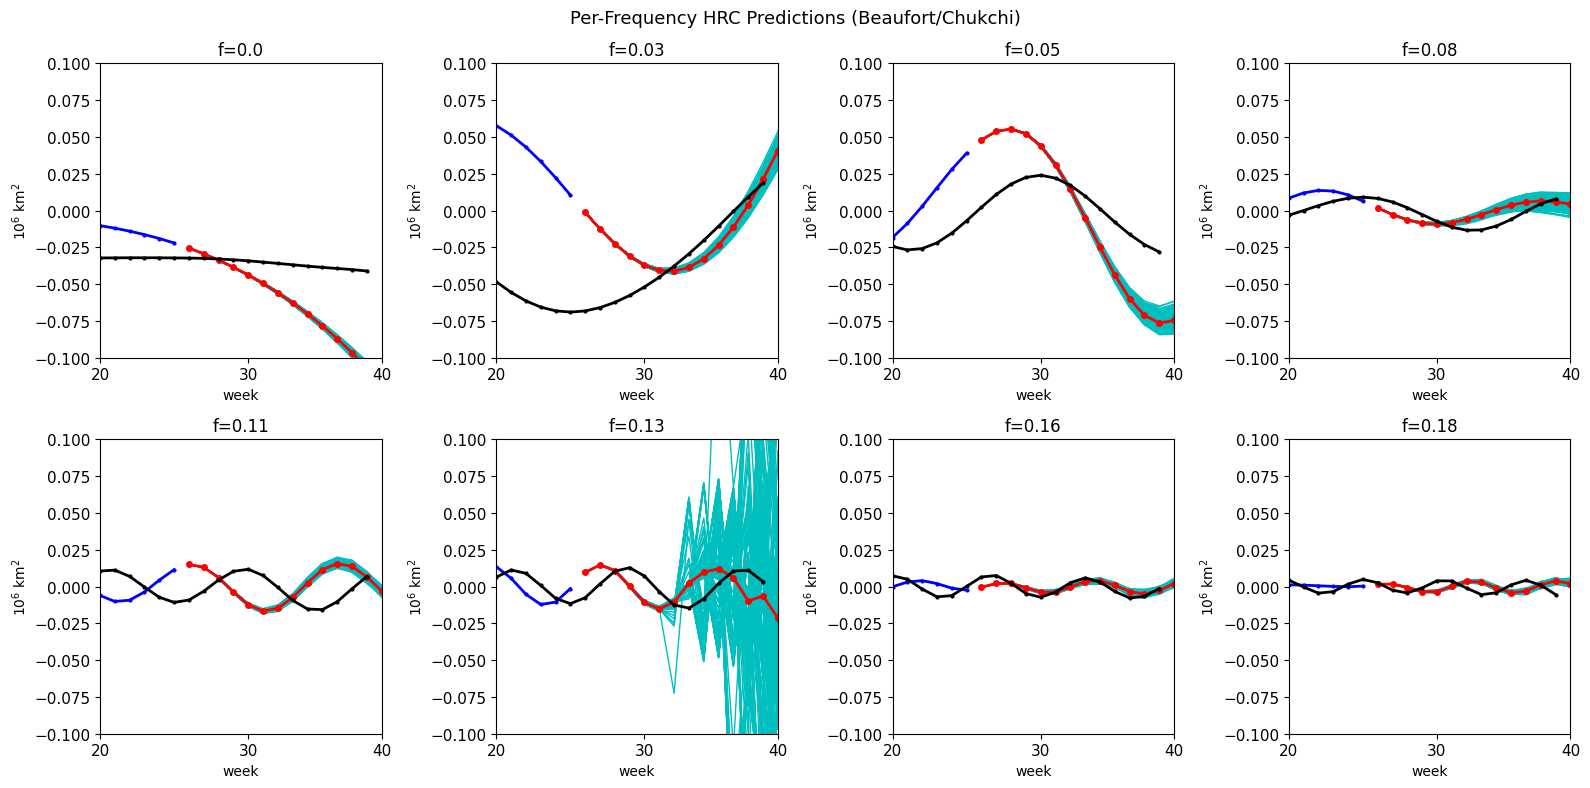

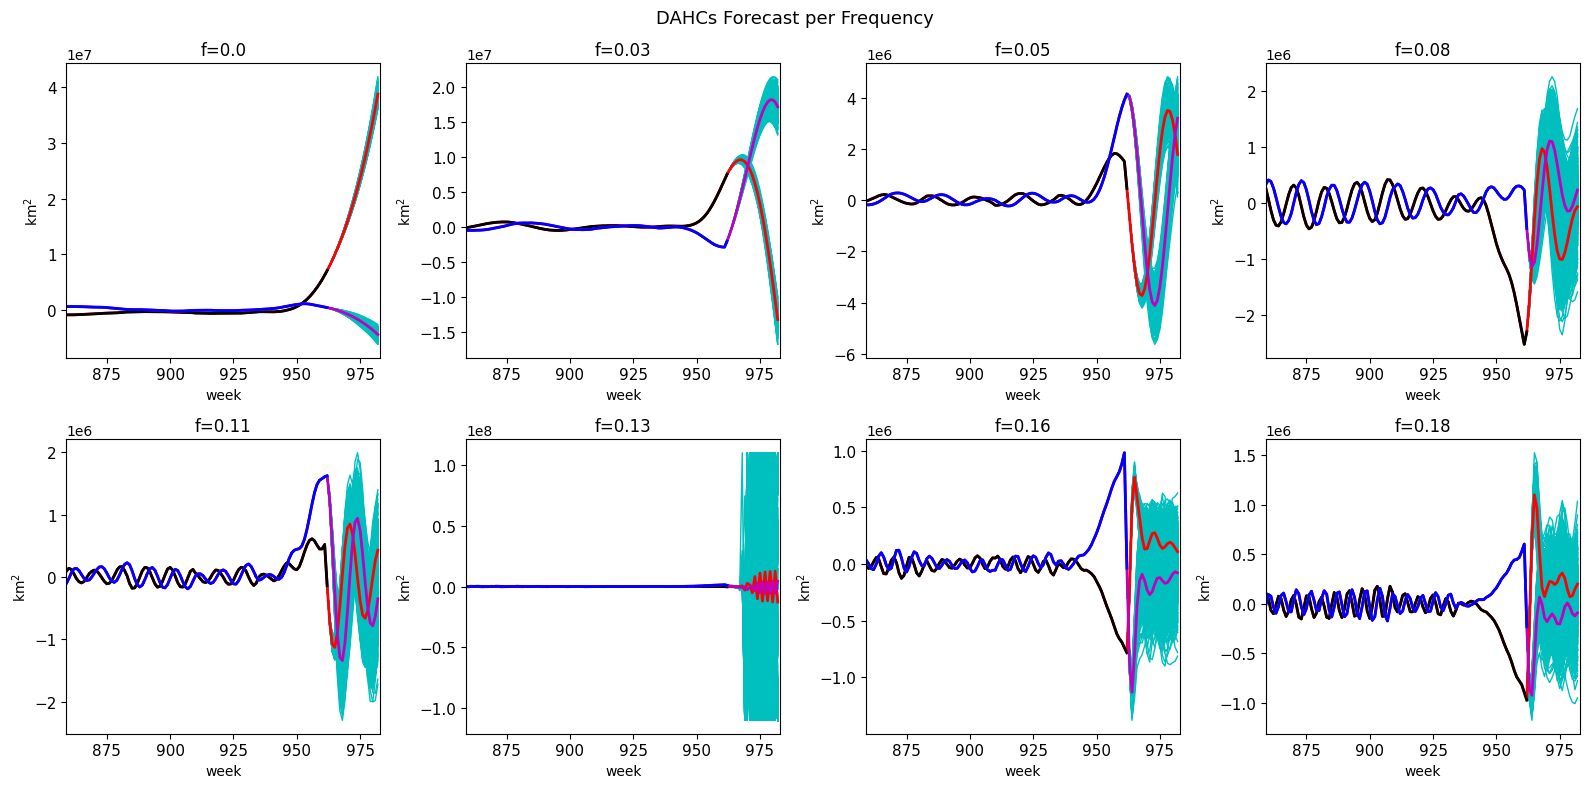

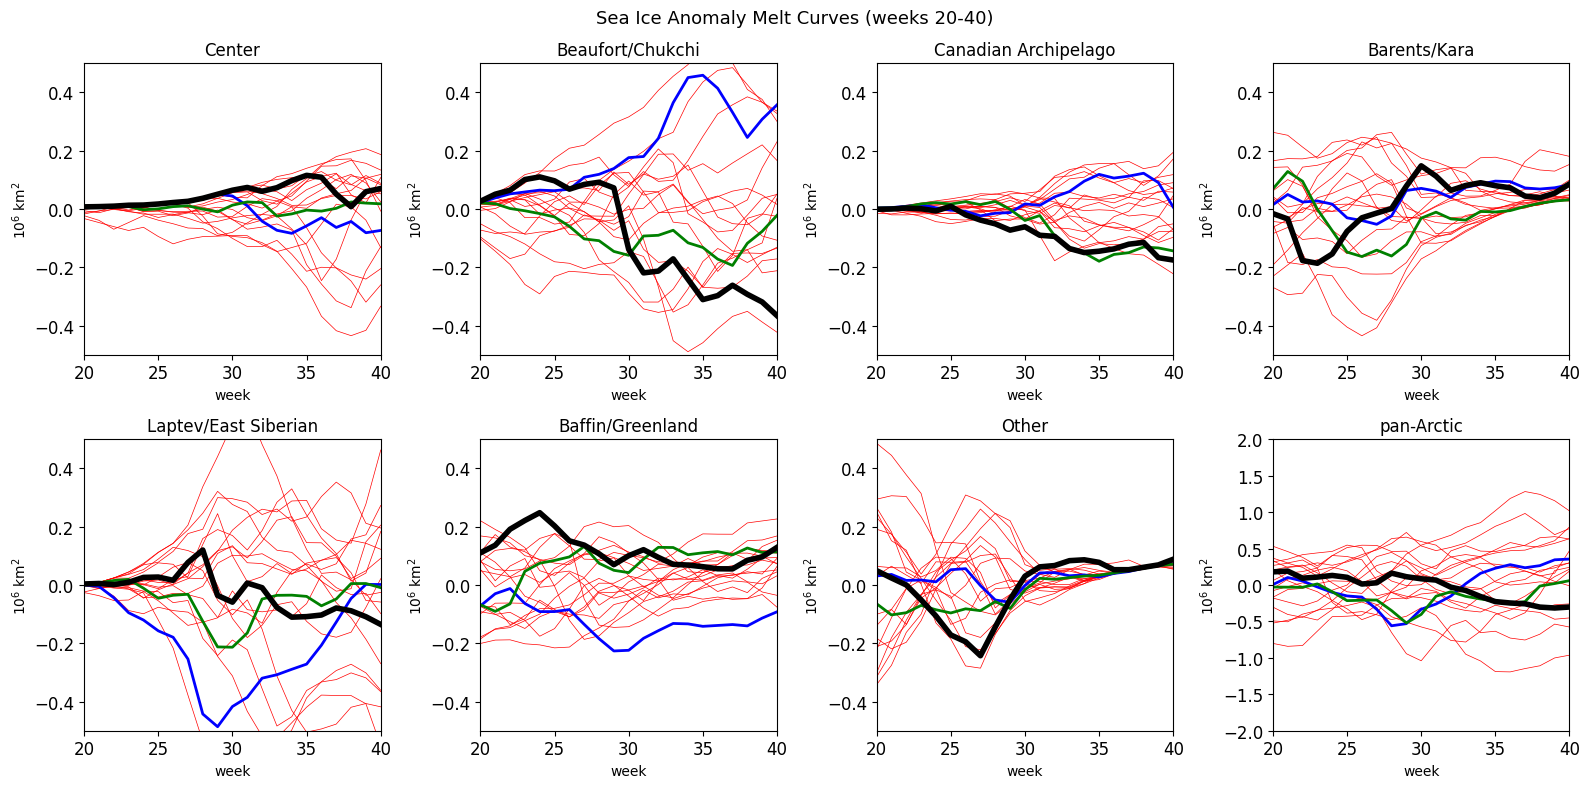

In [180]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# ── Load ROBSFF ───────────────────────────────────────────────────────────────
mat_ff = scipy.io.loadmat('ROBSFF.mat')
RRRF   = mat_ff['RRRF']   # shape (975, 7, 30)

# ── Fig 6 — Per-frequency HRC predictions (Beaufort region, ir=2) ─────────────
# MATLAB: for NF=1:2:15 → Python: range(0,15,2) = 0,2,4,6,8,10,12,14
ir      = 1        # Beaufort/Chukchi (MATLAB ir=2 → Python index 1)
lmax    = RXRC.shape[0]
t_plot  = yearst_full[:lmax]
x_start = yearst_full[18 * 52 + 20]
x_end   = yearst_full[min(lmax - 1, 18 * 52 + 39)]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
NFFF = 0
for NF in range(0, 15, 2):   # MATLAB NF=1:2:15 (1-indexed) → 0:2:14
    ax = axes.flat[NFFF]

    # Ensemble members (cyan)
    TRE = np.squeeze(RXT[:, ir, NF, :])   # (NXT, NT0)
    ax.plot(t_plot[NET_plot:NET_plot + LEAD + 1],
            TRE[NET_plot:NET_plot + LEAD + 1, :] / 1e6,
            'c-', linewidth=1)

   # Historical fit (blue) — mean over ensemble (axis 1 since slice gives (NXT, NT0))
    TR_mean = np.squeeze(np.mean(RXT[:lmax, ir, NF, :], axis=1))  # (lmax,)
    ax.plot(t_plot[:NET_plot],
            TR_mean[:NET_plot] / 1e6,
            'b.-', markersize=4, linewidth=2)

    # Forecast mean (red)
    ax.plot(t_plot[NET_plot:NET_plot + LEAD + 1],
            TR_mean[NET_plot:NET_plot + LEAD + 1] / 1e6,
            'r.-', markersize=8, linewidth=2)

    # Observations from ROBSFF (black)
    nrrf = min(RRRF.shape[0], lmax)
    ax.plot(t_plot[:nrrf], RRRF[:nrrf, ir, NF] / 1e6,
            'k.-', markersize=4, linewidth=2)

    ax.set_title(f'f={round(fE2[NF], 2)}')
    ax.set_xlim([x_start, x_end])
    ax.set_ylim([-0.1, 0.1])
    tick_idx = [18 * 52 + 20, 18 * 52 + 30, 18 * 52 + 39]
    valid    = [i for i in tick_idx if i < lmax]
    ax.set_xticks([yearst_full[i] for i in valid])
    ax.set_xticklabels(['20', '30', '40'])
    ax.set_ylabel('10$^6$ km$^2$')
    ax.set_xlabel('week')
    ax.tick_params(labelsize=11)
    NFFF += 1

plt.suptitle('Per-Frequency HRC Predictions (Beaufort/Chukchi)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Fig 7 — DAHCs forecast (AXT) per frequency ───────────────────────────────
# MATLAB: for NF=1:2:15 → shows ensemble mean of AXT[:,1,:,NF] and AXT[:,2,:,NF]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
NFFF = 0
for NF in range(0, 15, 2):
    ax = axes.flat[NFFF]

    # Ensemble members (cyan) — both DAHCs
    ax.plot(np.squeeze(AXT[:, 0, :, NF]), 'c-', linewidth=1)
    ax.plot(np.squeeze(AXT[:, 1, :, NF]), 'c-', linewidth=1)

    # Ensemble mean DAHC 1 (red = forecast, black = history)
    AXTF1 = np.squeeze(np.mean(AXT[:NE, 0, :, NF], axis=1))
    AXTO1 = np.squeeze(np.mean(AXT[:NA, 0, :, NF], axis=1))
    ax.plot(AXTF1, 'r-', linewidth=2)
    ax.plot(AXTO1, 'k-', linewidth=2)

    # Ensemble mean DAHC 2 (magenta = forecast, blue = history)
    AXTF2 = np.squeeze(np.mean(AXT[:NE, 1, :, NF], axis=1))
    AXTO2 = np.squeeze(np.mean(AXT[:NA, 1, :, NF], axis=1))
    ax.plot(AXTF2, 'm-', linewidth=2)
    ax.plot(AXTO2, 'b-', linewidth=2)

    ax.set_title(f'f={round(fE2[NF], 2)}')
    ax.set_xlim([NA - 2 * 52, NE])
    ax.set_ylabel('km$^2$')
    ax.set_xlabel('week')
    ax.tick_params(labelsize=11)
    NFFF += 1

plt.suptitle('DAHCs Forecast per Frequency', fontsize=13)
plt.tight_layout()
plt.show()

# ── Fig 8 — Anomaly melt curves (aiceyear) weeks 20-40 ───────────────────────
# MATLAB uses aiceyear which is anomalies reshaped like iceyear
# aiceyear shape should be (52, n_years, DD)
aiceyear = X[:n_hist, :].reshape(n_years, 52, DD).transpose(1, 0, 2)
aice2021 = X[n_hist:, :]

wk_slice = slice(19, 40)
x_weeks  = np.arange(20, 41)

titles_a = ['Center', 'Beaufort/Chukchi', 'Canadian Archipelago',
            'Barents/Kara', 'Laptev/East Siberian', 'Baffin/Greenland', 'Other']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for k in range(DD):
    ax = axes.flat[k]
    ax.plot(x_weeks, aiceyear[wk_slice, :, k] / 1e6, 'r', linewidth=0.5)
    ax.plot(x_weeks, aiceyear[wk_slice, -2, k] / 1e6, 'b', linewidth=2)
    ax.plot(x_weeks, aiceyear[wk_slice,  6, k] / 1e6, 'g', linewidth=2)
    n_cur = min(tweek - 19, len(x_weeks))
    if n_cur > 0:
        ax.plot(x_weeks[:n_cur], aice2021[19:19 + n_cur, k] / 1e6, 'k', linewidth=4)
    ax.set_title(titles_a[k] if k < len(titles_a) else f'Region {k+1}')
    ax.set_xlim([20, 40])
    ax.set_ylim([-0.5, 0.5])
    ax.set_xlabel('week')
    ax.set_ylabel('10$^6$ km$^2$')
    ax.tick_params(labelsize=12)

# Pan-Arctic anomaly
ax = axes.flat[7]
ax.plot(x_weeks, np.sum(aiceyear[wk_slice, :, :], axis=2)           / 1e6, 'r', linewidth=0.5)
ax.plot(x_weeks, np.sum(aiceyear[wk_slice, -2, :], axis=1)          / 1e6, 'b', linewidth=2)
ax.plot(x_weeks, np.sum(aiceyear[wk_slice,  6, :], axis=1)          / 1e6, 'g', linewidth=2)
n_cur = min(tweek - 19, len(x_weeks))
if n_cur > 0:
    ax.plot(x_weeks[:n_cur], np.sum(aice2021[19:19+n_cur, :], axis=1) / 1e6, 'k', linewidth=4)
ax.set_title('pan-Arctic')
ax.set_xlim([20, 40]); ax.set_ylim([-2, 2])
ax.set_xlabel('week'); ax.set_ylabel('10$^6$ km$^2$')
ax.tick_params(labelsize=12)

plt.suptitle('Sea Ice Anomaly Melt Curves (weeks 20-40)', fontsize=13)
plt.tight_layout()
plt.show()

In [175]:
# aiceyear should be iceext_c (centered but NOT deseasonalized)
# not X (which has seasonal cycle also removed)
iceext_c_hist = iceext_c[:n_hist, :]  # centered but seasonal still in
aiceyear_correct = iceext_c_hist.reshape(n_years, 52, DD).transpose(1, 0, 2)

print("aiceyear_correct weeks 20-25, year 6 (2012), col 1 (Beaufort):")
print(aiceyear_correct[19:25, 6, 1] / 1e6)
print("\nMATLAB aiceyear would show larger values since seasonal cycle kept in")

aiceyear_correct weeks 20-25, year 6 (2012), col 1 (Beaufort):
[0.3762853  0.34541433 0.29671    0.24821459 0.18614096 0.1246484 ]

MATLAB aiceyear would show larger values since seasonal cycle kept in


In [171]:
print("AXT shape:", AXT.shape)
for NF in range(0, 15, 2):
    vals = AXT[:, :, :, NF]
    print(f"NF={NF}, f={fE2[NF]:.2f}: max={np.nanmax(np.abs(vals)):.2e}, any_inf={np.any(np.isinf(vals))}, any_nan={np.any(np.isnan(vals))}")

AXT shape: (983, 2, 600, 20)
NF=0, f=0.00: max=4.19e+07, any_inf=False, any_nan=False
NF=2, f=0.03: max=2.14e+07, any_inf=False, any_nan=False
NF=4, f=0.05: max=5.63e+06, any_inf=False, any_nan=False
NF=6, f=0.08: max=2.53e+06, any_inf=False, any_nan=False
NF=8, f=0.11: max=2.30e+06, any_inf=False, any_nan=False
NF=10, f=0.13: max=1.10e+08, any_inf=False, any_nan=False
NF=12, f=0.16: max=1.38e+06, any_inf=False, any_nan=False
NF=14, f=0.18: max=1.53e+06, any_inf=False, any_nan=False


### September Prediction and Histogram

September indices: [971 972 973 974]
September years:   [2024.69230769 2024.71153846 2024.73076923 2024.75      ]
SeptSIE (Mkm2): 4.4694


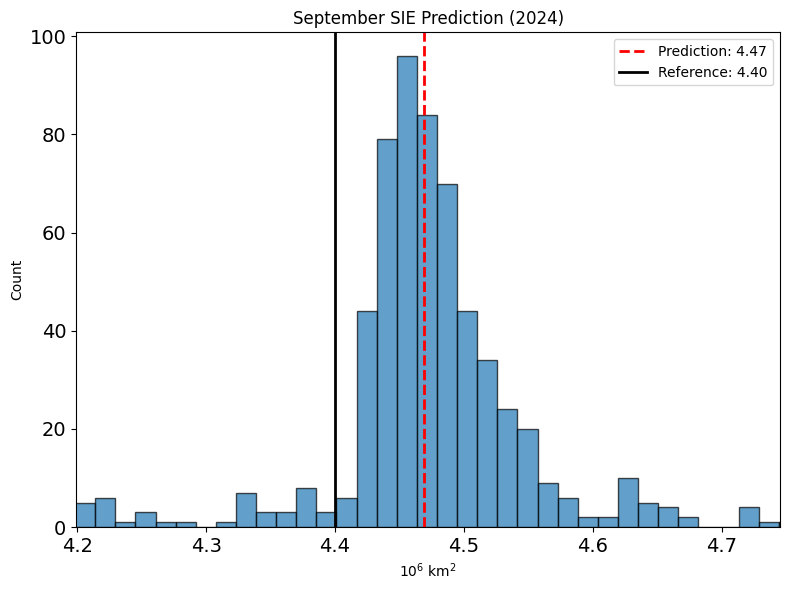

In [166]:
# ── September prediction ──────────────────────────────────────────────────────
t_forecast = yearst_full[NET_plot:NET_plot + LEAD + 1]
sept = []
for wk in range(36, 40):
    target    = 2024 + wk / 52
    local_idx = np.argmin(np.abs(t_forecast - target))
    sept.append(NET_plot + local_idx)
sept = np.array(sept)

print(f"September indices: {sept}")
print(f"September years:   {yearst_full[sept]}")

# FIX: RX0 already has icemean added — don't add it again
tmppp  = np.squeeze(np.sum(RX0, axis=1))   # (NXT, 600)
tmppp2 = np.mean(tmppp[sept, :], axis=0) / 1e6
sice   = np.mean(tmppp2)

print(f'SeptSIE (Mkm2): {sice:.4f}')

# Auto-scale histogram
p5, p95 = np.percentile(tmppp2, 5), np.percentile(tmppp2, 95)
margin  = (p95 - p5) * 0.5

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(tmppp2, bins=40, edgecolor='black', alpha=0.7)
ax.axvline(sice, color='r', linestyle='--', linewidth=2,
           label=f'Prediction: {sice:.2f}')
ax.axvline(4.40, color='k', linestyle='-', linewidth=2,
           label='Reference: 4.40')
ax.set_xlim([max(0, p5 - margin), p95 + margin])
ax.set_xlabel('10$^6$ km$^2$'); ax.set_ylabel('Count')
ax.set_title('September SIE Prediction (2024)')
ax.legend(); ax.tick_params(labelsize=14)
plt.tight_layout()
plt.show()

In [167]:
print("NA:", NA)
print("NE:", NE)
print("NXT:", NXT)
print("LEAD:", LEAD)
print("RXRC shape:", RXRC.shape)
print("RX0 shape:", RX0.shape)
print("yearst_full shape:", yearst_full.shape)
print("yearst_full first value:", yearst_full[0])
print("yearst_full last value:", yearst_full[-1])
print("icemean:", icemean)

NA: 963
NE: 983
NXT: 1059
LEAD: 20
RXRC shape: (1059, 7, 600)
RX0 shape: (1059, 7, 600)
yearst_full shape: (1059,)
yearst_full first value: 2006.0192307692307
yearst_full last value: 2026.3653846153848
icemean: [3163727.98995181 1385456.51569173  668388.67636793  885615.79995098
 1785540.17453828 1177764.25777884 1312181.28248893]


Running temporal robustness test...
 Years  N weeks    SeptSIE   Spread     Time
----------------------------------------------
0 >0:7 <0:0
1 >0:7 <0:0
2 >0:7 <0:0
3 >0:7 <0:0
4 >0:7 <0:0
5 >0:7 <0:0
6 >0:7 <0:0
7 >0:7 <0:0
8 >0:7 <0:0
9 >0:7 <0:0
10 >0:7 <0:0
11 >0:7 <0:0
12 >0:7 <0:0
13 >0:7 <0:0
14 >0:7 <0:0
15 >0:7 <0:0
16 >0:7 <0:0
17 >0:7 <0:0
18 >0:7 <0:0
19 >0:7 <0:0
20 >0:7 <0:0
21 >0:7 <0:0
22 >0:7 <0:0
23 >0:7 <0:0
24 >0:7 <0:0
25 >0:7 <0:0
26 >0:7 <0:0
27 >0:7 <0:0
28 >0:7 <0:0
29 >0:7 <0:0
30 >0:7 <0:0
31 >0:7 <0:0
32 >0:7 <0:0
33 >0:7 <0:0
34 >0:7 <0:0
35 >0:7 <0:0
36 >0:7 <0:0
37 >0:7 <0:0
38 >0:7 <0:0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  n_yr=10: sept_s=[463 463 463 463], years=[2014.92307692 2014.92307692 2014.92307692 2014.92307692]
    10      520    21.3981   0.0520     8.5s
0 >0:7 <0:0
1 >0:7 <0:0
2 >0:7 <0:0
3 >0:7 <0:0
4 >0:7 <0:0
5 >0:7 <0:0
6 >0:7 <0:0
7 >0:7 <0:0
8 >0:7 <0:0
9 >0:7 <0:0
10 >0:7 <0:0
11 >0:7 <0:0
12 >0:7 <0:0
13 >0:7 <0:0
14 >0:7 <0:0
15 >0:7 <0:0
16 >0:7 <0:0
17 >0:7 <0:0
18 >0:7 <0:0
19 >0:7 <0:0
20 >0:7 <0:0
21 >0:7 <0:0
22 >0:7 <0:0
23 >0:7 <0:0
24 >0:7 <0:0
25 >0:7 <0:0
26 >0:7 <0:0
27 >0:7 <0:0
28 >0:7 <0:0
29 >0:7 <0:0
30 >0:7 <0:0
31 >0:7 <0:0
32 >0:7 <0:0
33 >0:7 <0:0
34 >0:7 <0:0
35 >0:7 <0:0
36 >0:7 <0:0
37 >0:7 <0:0
38 >0:7 <0:0
  n_yr=12: sept_s=[567 567 567 567], years=[2016.92307692 2016.92307692 2016.92307692 2016.92307692]
    12      624    20.9882   0.0741     8.7s
0 >0:7 <0:0
1 >0:7 <0:0
2 >0:7 <0:0
3 >0:7 <0:0
4 >0:7 <0:0
5 >0:7 <0:0
6 >0:7 <0:0
7 >0:7 <0:0
8 >0:7 <0:0
9 >0:7 <0:0
10 >0:7 <0:0
11 >0:7 <0:0
12 >0:7 <0:0
13 >0:7 <0:0
14 >0:7 <0:0
15 >0:7 <0:0
16 >0:7 <0:0


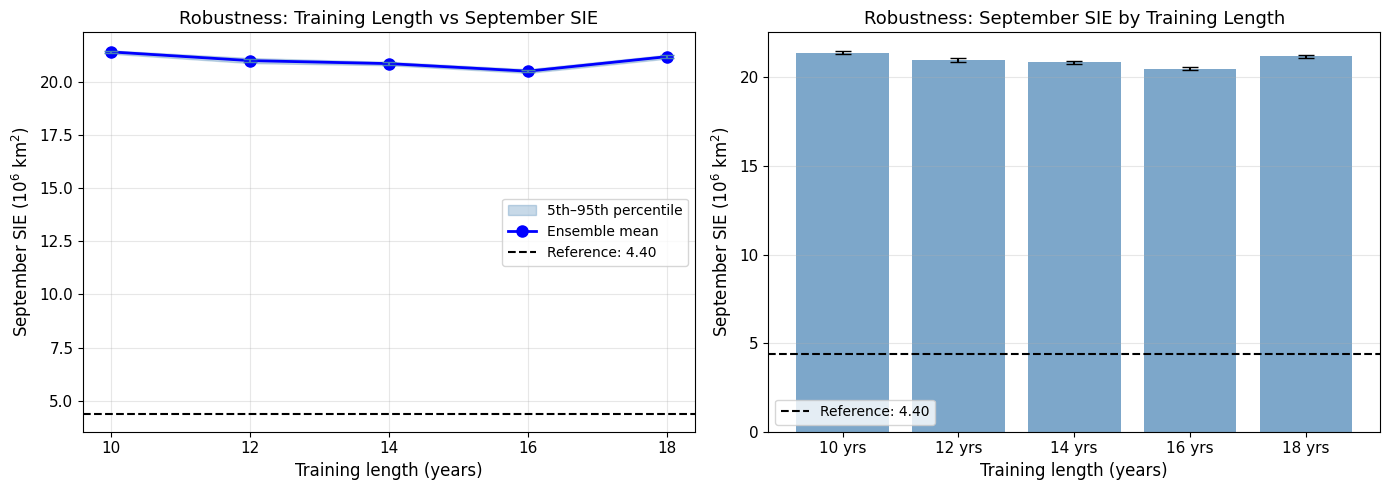

In [168]:

# ── Robustness Test: Temporal Subsets ────────────────────────────────────────
# Tests how September SIE prediction changes with different training lengths.
# Reruns DAHD + MSLM pipeline for each subset using the same parameters.

import time

training_years = [10, 12, 14, 16, 18]   # years of training data
weeks_per_year = 52
LEAD_rob       = 20
NT0_rob        = 100   # smaller ensemble for speed (200 for final run)

results = {
    'years':      [],
    'sice_mean':  [],
    'sice_std':   [],
    'sice_p5':    [],
    'sice_p95':   [],
    'n_weeks':    [],
}

print("Running temporal robustness test...")
print(f"{'Years':>6} {'N weeks':>8} {'SeptSIE':>10} {'Spread':>8} {'Time':>8}")
print("-" * 46)

for n_yr in training_years:
    t0 = time.time()

    # ── Subset data ───────────────────────────────────────────────────────────
    n_weeks = n_yr * weeks_per_year
    iceext_sub  = iceextobs[:n_weeks, :]
    icemean_sub = np.mean(iceext_sub, axis=0)

    # Remove seasonal cycle
    iceext_c_sub = iceext_sub - icemean_sub
    anom_sub     = np.zeros_like(iceext_c_sub)
    scycle_sub   = np.zeros((52, DD))

    for j in range(DD):
        for i in range(52):
            idx               = np.arange(i, iceext_c_sub.shape[0], 52)
            scycle_sub[i, j]  = np.mean(iceext_c_sub[idx, j])
            anom_sub[idx, j]  = iceext_c_sub[idx, j] - scycle_sub[i, j]

    X_sub = anom_sub

    # ── DAHD analysis ─────────────────────────────────────────────────────────
    W_rob   = 39
    WW_rob  = 2 * W_rob - 1
    D_rob   = X_sub.shape[1]
    NFE_rob = W_rob

    fE2_s, VP_s, FEP_s = DAHD4freq_part_weight(
        X_sub, W_rob, NFE_rob, D_rob, 'bartlett'
    )

    # ── Compute DAHMs ─────────────────────────────────────────────────────────
    EP_s = np.zeros(((2 * W_rob - 1) * D_rob, 2 * D_rob, NFE_rob))
    for iff in range(NFE_rob):
        ER = DAHM4_ex(FEP_s[:, :, iff], W_rob, iff, 2 * D_rob)
        EP_s[:, :, iff] = np.reshape(ER, ((2 * W_rob - 1) * D_rob, 2 * D_rob))

    # ── MSLM forecast ─────────────────────────────────────────────────────────
    NFS_s = 0
    NFE_s = 20

    NA_s  = X_sub.shape[0] - EP_s.shape[0] // D_rob + 1
    NE_s  = NA_s + LEAD_rob
    NXT_s = NE_s + EP_s.shape[0] // D_rob - 1

    RXT_s = np.zeros((NXT_s, DD, NFE_s, NT0_rob))

    np.random.seed(0)
    for NF in range(NFS_s, NFE_s):
        NM_s   = D_rob if NF == 0 else 2 * D_rob
        ER_s   = EP_s[:, :NM_s, NF]
        A_s    = dahc(X_sub, ER_s)
        indm_s = np.arange(NM_s)
        DMD_s  = A_s[:, indm_s]

        np.random.seed(0)
        irp_s = np.random.randn(NM_s, NE_s, NT0_rob)

        if NF == 0:
            xx_s, _, _, _ = MSLM_FCST(
                LEAD_rob, DMD_s, 0, 2, NT0_rob, 0, 1, 0, 0, 0, irp_s)
        else:
            xx_s, _, _, _ = MSLM_FCST(
                LEAD_rob, DMD_s, 1, 2, NT0_rob, 0, 1, 1, 1, 1, irp_s)

        RXZ_s = np.zeros((NXT_s, DD, NT0_rob))
        for KK in range(NT0_rob):
            pcf = hrc(xx_s[:, indm_s, KK], ER_s[:, indm_s], DD,
                      np.arange(A_s[:, indm_s].shape[1]))
            n3  = min(pcf.shape[0], NXT_s)
            RXZ_s[:n3, :, KK] = pcf[:n3, :]
        RXT_s[:, :, NF, :] = RXZ_s

    # ── Post-processing ───────────────────────────────────────────────────────
    indf_s = np.arange(NFE_s)
    RX_s   = np.sum(RXT_s[:, :, indf_s, :], axis=2)   # (NXT_s, DD, NT0_rob)

    # Add seasonal cycle back
    for j in range(DD):
        for i in range(52):
            for k in range(NT0_rob):
                idx2 = np.arange(i, RX_s.shape[0], 52)
                idx2 = idx2[idx2 < RX_s.shape[0]]
                RX_s[idx2, j, k] += scycle_sub[i, j]

    RX0_s = RX_s.copy()
    for k in range(NT0_rob):
        RX0_s[:, :, k] += icemean_sub
    RX0_s[RX0_s < 0] = 0

    # ── September prediction ──────────────────────────────────────────────────
    # September prediction — find within forecast window only
    NET_s = NA_s - 1
    t_sub = yearst_full[:NXT_s]  # time axis for this subset

    # Forecast window rows
    t_forecast_s = t_sub[NET_s:NET_s + LEAD_rob + 1]

    # September 2024 weeks 36-39 within forecast window
    sept_s = []
    for wk in range(36, 40):
        target    = 2024 + wk / 52
        local_idx = np.argmin(np.abs(t_forecast_s - target))
        global_idx = NET_s + local_idx
        if global_idx < NXT_s:
            sept_s.append(global_idx)
    sept_s = np.array(sept_s)

    # Fallback if no valid indices found
    if len(sept_s) == 0:
        sept_s = np.arange(NET_s + 8, min(NET_s + 12, NXT_s))

    print(f"  n_yr={n_yr}: sept_s={sept_s}, years={t_sub[sept_s]}")

    tmppp_s  = np.squeeze(np.sum(RX0_s, axis=1))   # (NXT_s, NT0_rob)
    tmppp1_s = tmppp_s + np.sum(icemean_sub)
    tmppp2_s = np.mean(tmppp1_s[sept_s, :], axis=0) / 1e6

    sice_s = float(np.mean(tmppp2_s))
    std_s  = float(np.std(tmppp2_s, ddof=1))
    p5_s   = float(np.percentile(tmppp2_s, 5))
    p95_s  = float(np.percentile(tmppp2_s, 95))

    results['years'].append(n_yr)
    results['n_weeks'].append(n_weeks)
    results['sice_mean'].append(sice_s)
    results['sice_std'].append(std_s)
    results['sice_p5'].append(p5_s)
    results['sice_p95'].append(p95_s)

    elapsed = time.time() - t0
    print(f"{n_yr:>6} {n_weeks:>8} {sice_s:>10.4f} {std_s:>8.4f} {elapsed:>7.1f}s")

print("\nDone!")

# ── Results Table ─────────────────────────────────────────────────────────────
print("\n── Temporal Robustness Summary ──────────────────────────────────────")
print(f"{'Training (yrs)':>15} {'N weeks':>8} {'SeptSIE':>10} {'Std':>8} {'5th pct':>8} {'95th pct':>9}")
print("-" * 62)
for i in range(len(results['years'])):
    print(f"{results['years'][i]:>15} "
          f"{results['n_weeks'][i]:>8} "
          f"{results['sice_mean'][i]:>10.4f} "
          f"{results['sice_std'][i]:>8.4f} "
          f"{results['sice_p5'][i]:>8.4f} "
          f"{results['sice_p95'][i]:>9.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: line plot with uncertainty band
ax = axes[0]
ax.fill_between(results['years'],
                results['sice_p5'], results['sice_p95'],
                alpha=0.3, color='steelblue', label='5th–95th percentile')
ax.plot(results['years'], results['sice_mean'],
        'bo-', linewidth=2, markersize=8, label='Ensemble mean')
ax.errorbar(results['years'], results['sice_mean'],
            yerr=results['sice_std'],
            fmt='none', color='steelblue', capsize=5, linewidth=1.5)
ax.axhline(4.40, color='k', linestyle='--', linewidth=1.5, label='Reference: 4.40')
ax.set_xlabel('Training length (years)', fontsize=12)
ax.set_ylabel('September SIE (10$^6$ km$^2$)', fontsize=12)
ax.set_title('Robustness: Training Length vs September SIE', fontsize=13)
ax.set_xticks(training_years)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=11)

# Right: bar chart with error bars
ax = axes[1]
x   = np.arange(len(results['years']))
err = [np.array(results['sice_mean']) - np.array(results['sice_p5']),
       np.array(results['sice_p95']) - np.array(results['sice_mean'])]
bars = ax.bar(x, results['sice_mean'], yerr=err,
              color='steelblue', alpha=0.7, capsize=6,
              error_kw={'linewidth': 1.5})
ax.axhline(4.40, color='k', linestyle='--', linewidth=1.5, label='Reference: 4.40')
ax.set_xlabel('Training length (years)', fontsize=12)
ax.set_ylabel('September SIE (10$^6$ km$^2$)', fontsize=12)
ax.set_title('Robustness: September SIE by Training Length', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f'{y} yrs' for y in results['years']])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()


Running temporal robustness test...
 Years  N weeks    SeptSIE   Spread     Time
----------------------------------------------
0 >0:7 <0:0
1 >0:7 <0:0
2 >0:7 <0:0
3 >0:7 <0:0
4 >0:7 <0:0
5 >0:7 <0:0
6 >0:7 <0:0
7 >0:7 <0:0
8 >0:7 <0:0
9 >0:7 <0:0
10 >0:7 <0:0
11 >0:7 <0:0
12 >0:7 <0:0
13 >0:7 <0:0
14 >0:7 <0:0
15 >0:7 <0:0
16 >0:7 <0:0
17 >0:7 <0:0
18 >0:7 <0:0
19 >0:7 <0:0
20 >0:7 <0:0
21 >0:7 <0:0
22 >0:7 <0:0
23 >0:7 <0:0
24 >0:7 <0:0
25 >0:7 <0:0
26 >0:7 <0:0
27 >0:7 <0:0
28 >0:7 <0:0
29 >0:7 <0:0
30 >0:7 <0:0
31 >0:7 <0:0
32 >0:7 <0:0
33 >0:7 <0:0
34 >0:7 <0:0
35 >0:7 <0:0
36 >0:7 <0:0
37 >0:7 <0:0
38 >0:7 <0:0


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  n_yr=10: sept years=[2014.69230769 2014.71153846 2014.73076923 2014.75      ], forecast end=2014.92
    10      520     4.9961   0.0130     9.3s
0 >0:7 <0:0
1 >0:7 <0:0
2 >0:7 <0:0
3 >0:7 <0:0
4 >0:7 <0:0
5 >0:7 <0:0
6 >0:7 <0:0
7 >0:7 <0:0
8 >0:7 <0:0
9 >0:7 <0:0
10 >0:7 <0:0
11 >0:7 <0:0
12 >0:7 <0:0
13 >0:7 <0:0
14 >0:7 <0:0
15 >0:7 <0:0
16 >0:7 <0:0
17 >0:7 <0:0
18 >0:7 <0:0
19 >0:7 <0:0
20 >0:7 <0:0
21 >0:7 <0:0
22 >0:7 <0:0
23 >0:7 <0:0
24 >0:7 <0:0
25 >0:7 <0:0
26 >0:7 <0:0
27 >0:7 <0:0
28 >0:7 <0:0
29 >0:7 <0:0
30 >0:7 <0:0
31 >0:7 <0:0
32 >0:7 <0:0
33 >0:7 <0:0
34 >0:7 <0:0
35 >0:7 <0:0
36 >0:7 <0:0
37 >0:7 <0:0
38 >0:7 <0:0
  n_yr=12: sept years=[2016.69230769 2016.71153846 2016.73076923 2016.75      ], forecast end=2016.92
    12      624     4.5388   0.0170    12.6s
0 >0:7 <0:0
1 >0:7 <0:0
2 >0:7 <0:0
3 >0:7 <0:0
4 >0:7 <0:0
5 >0:7 <0:0
6 >0:7 <0:0
7 >0:7 <0:0
8 >0:7 <0:0
9 >0:7 <0:0
10 >0:7 <0:0
11 >0:7 <0:0
12 >0:7 <0:0
13 >0:7 <0:0
14 >0:7 <0:0
15 >0:7 <0:0
16 >0:7 <0:

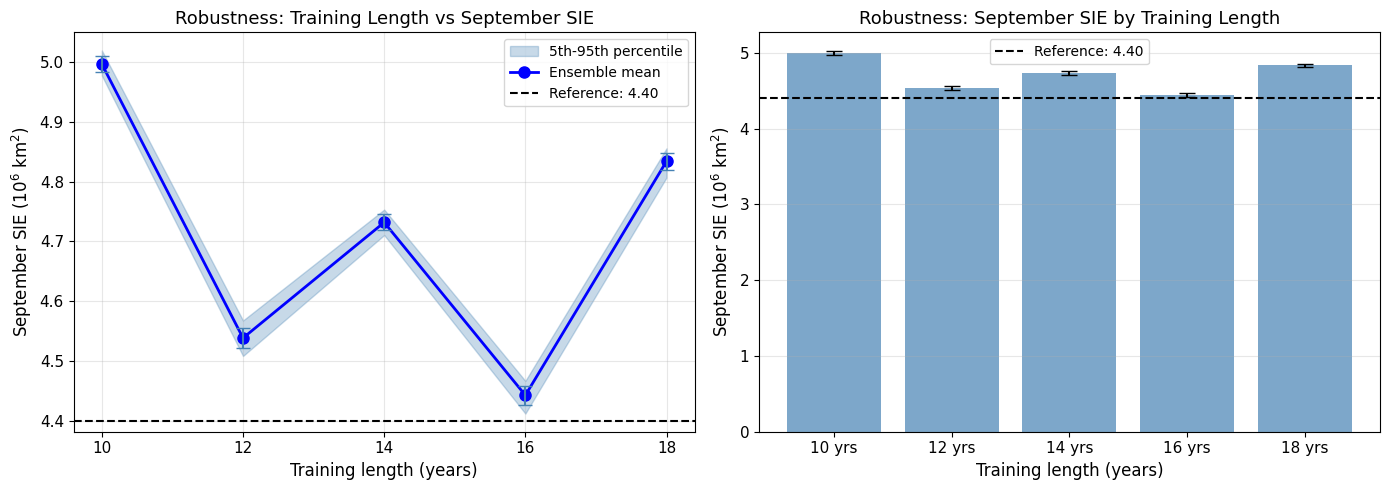

In [169]:
import time

# ── Robustness Test: Temporal Subsets ────────────────────────────────────────
training_years = [10, 12, 14, 16, 18]
weeks_per_year = 52
LEAD_rob       = 20
NT0_rob        = 100

results_years    = []
results_nweeks   = []
results_mean     = []
results_std      = []
results_p5       = []
results_p95      = []

print("Running temporal robustness test...")
print(f"{'Years':>6} {'N weeks':>8} {'SeptSIE':>10} {'Spread':>8} {'Time':>8}")
print("-" * 46)

for n_yr in training_years:
    t0 = time.time()

    # Subset data
    n_weeks      = n_yr * weeks_per_year
    iceext_sub   = iceextobs[:n_weeks, :]
    icemean_sub  = np.mean(iceext_sub, axis=0)
    iceext_c_sub = iceext_sub - icemean_sub
    anom_sub     = np.zeros_like(iceext_c_sub)
    scycle_sub   = np.zeros((52, DD))

    for j in range(DD):
        for i in range(52):
            idx              = np.arange(i, iceext_c_sub.shape[0], 52)
            scycle_sub[i, j] = np.mean(iceext_c_sub[idx, j])
            anom_sub[idx, j] = iceext_c_sub[idx, j] - scycle_sub[i, j]

    X_sub = anom_sub

    # DAHD analysis
    W_rob   = 39
    D_rob   = X_sub.shape[1]
    NFE_rob = W_rob
    fE2_s, VP_s, FEP_s = DAHD4freq_part_weight(X_sub, W_rob, NFE_rob, D_rob, 'bartlett')

    # Compute DAHMs
    EP_s = np.zeros(((2 * W_rob - 1) * D_rob, 2 * D_rob, NFE_rob))
    for iff in range(NFE_rob):
        ER = DAHM4_ex(FEP_s[:, :, iff], W_rob, iff, 2 * D_rob)
        EP_s[:, :, iff] = np.reshape(ER, ((2 * W_rob - 1) * D_rob, 2 * D_rob))

    # MSLM forecast
    NFE_s = 20
    NA_s  = X_sub.shape[0] - EP_s.shape[0] // D_rob + 1
    NE_s  = NA_s + LEAD_rob
    NXT_s = NE_s + EP_s.shape[0] // D_rob - 1
    RXT_s = np.zeros((NXT_s, DD, NFE_s, NT0_rob))

    np.random.seed(0)
    for NF in range(NFE_s):
        NM_s   = D_rob if NF == 0 else 2 * D_rob
        ER_s   = EP_s[:, :NM_s, NF]
        A_s    = dahc(X_sub, ER_s)
        indm_s = np.arange(NM_s)
        DMD_s  = A_s[:, indm_s]
        np.random.seed(0)
        irp_s  = np.random.randn(NM_s, NE_s, NT0_rob)
        if NF == 0:
            xx_s, _, _, _ = MSLM_FCST(LEAD_rob, DMD_s, 0, 2, NT0_rob, 0, 1, 0, 0, 0, irp_s)
        else:
            xx_s, _, _, _ = MSLM_FCST(LEAD_rob, DMD_s, 1, 2, NT0_rob, 0, 1, 1, 1, 1, irp_s)
        RXZ_s = np.zeros((NXT_s, DD, NT0_rob))
        for KK in range(NT0_rob):
            pcf = hrc(xx_s[:, indm_s, KK], ER_s[:, indm_s], DD,
                      np.arange(A_s[:, indm_s].shape[1]))
            n3  = min(pcf.shape[0], NXT_s)
            RXZ_s[:n3, :, KK] = pcf[:n3, :]
        RXT_s[:, :, NF, :] = RXZ_s

    # Post-processing
    RX_s = np.sum(RXT_s, axis=2)
    for j in range(DD):
        for i in range(52):
            for k in range(NT0_rob):
                idx2 = np.arange(i, RX_s.shape[0], 52)
                idx2 = idx2[idx2 < RX_s.shape[0]]
                RX_s[idx2, j, k] += scycle_sub[i, j]

    RX0_s = RX_s.copy()
    for k in range(NT0_rob):
        RX0_s[:, :, k] += icemean_sub
    RX0_s[RX0_s < 0] = 0

    # September prediction — use END of this subset's forecast window
    NET_s        = NA_s - 1
    t_sub        = yearst_full[:NXT_s]
    t_forecast_s = t_sub[NET_s:NET_s + LEAD_rob + 1]

    # End year of this subset's forecast
    forecast_end_year = int(t_forecast_s[-1])

    sept_s = []
    for wk in range(36, 40):
        target     = forecast_end_year + wk / 52
        local_idx  = np.argmin(np.abs(t_forecast_s - target))
        global_idx = NET_s + local_idx
        if global_idx < NXT_s:
            sept_s.append(global_idx)
    sept_s = np.array(sept_s)

    if len(sept_s) == 0:
        sept_s = np.arange(NET_s + 8, min(NET_s + 12, NXT_s))

    print(f"  n_yr={n_yr}: sept years={t_sub[sept_s]}, forecast end={t_forecast_s[-1]:.2f}")    

    # FIX: RX0_s already has icemean_sub added — don't add again
    tmppp_s  = np.squeeze(np.sum(RX0_s, axis=1))
    tmppp2_s = np.mean(tmppp_s[sept_s, :], axis=0) / 1e6

    sice_s = float(np.mean(tmppp2_s))
    std_s  = float(np.std(tmppp2_s, ddof=1))
    p5_s   = float(np.percentile(tmppp2_s, 5))
    p95_s  = float(np.percentile(tmppp2_s, 95))

    results_years.append(n_yr)
    results_nweeks.append(n_weeks)
    results_mean.append(sice_s)
    results_std.append(std_s)
    results_p5.append(p5_s)
    results_p95.append(p95_s)

    elapsed = time.time() - t0
    print(f"{n_yr:>6} {n_weeks:>8} {sice_s:>10.4f} {std_s:>8.4f} {elapsed:>7.1f}s")

print("\nDone!")

# Results table
print("\n── Temporal Robustness Summary ──────────────────────────────────")
print(f"{'Training (yrs)':>15} {'SeptSIE':>10} {'Std':>8} {'5th pct':>8} {'95th pct':>9}")
print("-" * 54)
for i in range(len(results_years)):
    print(f"{results_years[i]:>15} {results_mean[i]:>10.4f} {results_std[i]:>8.4f} {results_p5[i]:>8.4f} {results_p95[i]:>9.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.fill_between(results_years, results_p5, results_p95,
                alpha=0.3, color='steelblue', label='5th-95th percentile')
ax.plot(results_years, results_mean, 'bo-', linewidth=2, markersize=8, label='Ensemble mean')
ax.errorbar(results_years, results_mean, yerr=results_std,
            fmt='none', color='steelblue', capsize=5, linewidth=1.5)
ax.axhline(4.40, color='k', linestyle='--', linewidth=1.5, label='Reference: 4.40')
ax.set_xlabel('Training length (years)', fontsize=12)
ax.set_ylabel('September SIE (10$^6$ km$^2$)', fontsize=12)
ax.set_title('Robustness: Training Length vs September SIE', fontsize=13)
ax.set_xticks(training_years)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=11)

ax = axes[1]
x   = np.arange(len(results_years))
err = [np.array(results_mean) - np.array(results_p5),
       np.array(results_p95) - np.array(results_mean)]
ax.bar(x, results_mean, yerr=err, color='steelblue', alpha=0.7,
       capsize=6, error_kw={'linewidth': 1.5})
ax.axhline(4.40, color='k', linestyle='--', linewidth=1.5, label='Reference: 4.40')
ax.set_xlabel('Training length (years)', fontsize=12)
ax.set_ylabel('September SIE (10$^6$ km$^2$)', fontsize=12)
ax.set_title('Robustness: September SIE by Training Length', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f'{y} yrs' for y in results_years])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

In [170]:
# Debug September rows in robustness
print("For n_yr=18 (last iteration):")
print("sept_s:", sept_s)
print("yearst_full[sept_s]:", yearst_full[sept_s])
print()
print("RX0_s shape:", RX0_s.shape)
print("RX0_s[sept_s, :, :5] (first 5 ensemble members):")
print(RX0_s[sept_s, :, :5])
print()
print("icemean_sub:", icemean_sub)
print("sum(icemean_sub):", np.sum(icemean_sub))
print()
print("tmppp_s[sept_s, :5]:", np.squeeze(np.sum(RX0_s, axis=1))[sept_s, :5])
print("tmppp2_s[:5]:", np.mean(np.squeeze(np.sum(RX0_s, axis=1))[sept_s, :], axis=0)[:5] / 1e6)

For n_yr=18 (last iteration):
sept_s: [867 868 869 870]
yearst_full[sept_s]: [2022.69230769 2022.71153846 2022.73076923 2022.75      ]

RX0_s shape: (956, 7, 100)
RX0_s[sept_s, :, :5] (first 5 ensemble members):
[[[2.93944274e+06 2.94596470e+06 2.94388719e+06 2.94187458e+06
   2.94246609e+06]
  [8.23476412e+05 8.21256553e+05 8.15121084e+05 8.29242782e+05
   8.22401486e+05]
  [4.66414674e+05 4.69146770e+05 4.69592683e+05 4.68446069e+05
   4.67318930e+05]
  [1.07705583e+05 1.05880006e+05 1.15112185e+05 1.11212515e+05
   1.02827066e+05]
  [3.90861626e+05 3.76315138e+05 3.91628994e+05 3.89276001e+05
   3.84800768e+05]
  [1.63596822e+05 1.68218210e+05 1.65636300e+05 1.66957027e+05
   1.66222176e+05]
  [1.74635840e+04 1.23978439e+03 2.26613749e+03 6.15382131e+03
   5.93617716e+03]]

 [[2.91888569e+06 2.92542100e+06 2.92257229e+06 2.92149428e+06
   2.92167728e+06]
  [6.93222430e+05 6.87662251e+05 6.84032666e+05 6.96685596e+05
   6.93048304e+05]
  [4.57996326e+05 4.63757749e+05 4.61949414e+05 